In [74]:
import pandas as pd 
import numpy as np 
import MetaTrader5 as mt5

In [75]:
mt5.initialize()

True

In [76]:
import datetime
import pytz


timezone = pytz.timezone("Etc/UTC")
# Convert the selected dates to datetime objects and set timezone



utc_from = datetime.datetime(2024, 11, 14, tzinfo=timezone)
utc_to = datetime.datetime(2024, 11, 15, tzinfo=timezone)


In [77]:
rates = mt5.copy_ticks_range("EURUSD", utc_from, utc_to,mt5.COPY_TICKS_ALL)

In [78]:
df = pd.DataFrame(rates)

In [79]:
df['time'] = pd.to_datetime(df['time'], unit='s')
df.to_csv("October2.csv")

In [80]:
df

,time,bid,ask,last,volume,time_msc,flags,volume_real
0,2024-11-14 00:01:00,1.05626,1.05653,0.0,0,1731542460658,134,0.0
1,2024-11-14 00:01:00,1.05626,1.05654,0.0,0,1731542460848,4,0.0
2,2024-11-14 00:01:02,1.05626,1.05680,0.0,0,1731542462154,4,0.0
3,2024-11-14 00:01:09,1.05624,1.05680,0.0,0,1731542469706,130,0.0
4,2024-11-14 00:01:10,1.05626,1.05669,0.0,0,1731542470097,134,0.0
...,...,...,...,...,...,...,...,...
62304,2024-11-14 23:59:59,1.05295,1.05334,0.0,0,1731628799433,134,0.0
62305,2024-11-14 23:59:59,1.05303,1.05343,0.0,0,1731628799576,134,0.0
62306,2024-11-14 23:59:59,1.05301,1.05338,0.0,0,1731628799673,134,0.0
62307,2024-11-14 23:59:59,1.05299,1.05336,0.0,0,1731628799903,134,0.0


In [81]:

df.set_index('time', inplace=True)

# Calculate mid-price (average of bid and ask)
df['mid_price'] = (df['bid'] + df['ask']) / 2

# Resample data to 2-minute intervals and calculate OHLC for mid-price
ohlc_resampled = df['mid_price'].resample('5T').agg(['first', 'max', 'min', 'last'])

# Rename columns for clarity
ohlc_resampled.rename(columns={
    'first': 'open',
    'max': 'high',
    'min': 'low',
    'last': 'close'
}, inplace=True)

# Calculate spread (ask - bid)
df['spread'] = df['ask'] - df['bid']

# Resample data to calculate spread statistics
spread_stats = df['spread'].resample('5T').agg(['max', 'min'])
spread_stats.rename(columns={'max': 'spread_high', 'min': 'spread_low'}, inplace=True)

# Merge OHLC and spread data
result = pd.concat([ohlc_resampled, spread_stats], axis=1)

# Display the resulting DataFrame
print(result)


                         open      high       low     close  spread_high  \
time                                                                       
2024-11-14 00:00:00  1.056395  1.056530  1.056210  1.056240      0.00056   
2024-11-14 00:05:00  1.056230  1.056400  1.055905  1.056265      0.00076   
2024-11-14 00:10:00  1.056440  1.056440  1.055895  1.056035      0.00094   
2024-11-14 00:15:00  1.056035  1.056310  1.055930  1.056085      0.00046   
2024-11-14 00:20:00  1.056110  1.056115  1.055960  1.055995      0.00040   
...                       ...       ...       ...       ...          ...   
2024-11-14 23:35:00  1.052310  1.052340  1.052250  1.052300      0.00006   
2024-11-14 23:40:00  1.052300  1.052480  1.052300  1.052435      0.00013   
2024-11-14 23:45:00  1.052455  1.052770  1.052455  1.052740      0.00008   
2024-11-14 23:50:00  1.052745  1.052925  1.052740  1.052915      0.00007   
2024-11-14 23:55:00  1.052910  1.053240  1.052885  1.053150      0.00041   

           

C:\Users\hevar\AppData\Local\Temp\ipykernel_17076\2949908625.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ohlc_resampled = df['mid_price'].resample('5T').agg(['first', 'max', 'min', 'last'])
C:\Users\hevar\AppData\Local\Temp\ipykernel_17076\2949908625.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  spread_stats = df['spread'].resample('5T').agg(['max', 'min'])


In [82]:
result

,open,high,low,close,spread_high,spread_low
time,,,,,,
2024-11-14 00:00:00,1.056395,1.056530,1.056210,1.056240,0.00056,0.00014
2024-11-14 00:05:00,1.056230,1.056400,1.055905,1.056265,0.00076,0.00012
2024-11-14 00:10:00,1.056440,1.056440,1.055895,1.056035,0.00094,0.00020
2024-11-14 00:15:00,1.056035,1.056310,1.055930,1.056085,0.00046,0.00006
2024-11-14 00:20:00,1.056110,1.056115,1.055960,1.055995,0.00040,0.00020
...,...,...,...,...,...,...
2024-11-14 23:35:00,1.052310,1.052340,1.052250,1.052300,0.00006,0.00004
2024-11-14 23:40:00,1.052300,1.052480,1.052300,1.052435,0.00013,0.00004
2024-11-14 23:45:00,1.052455,1.052770,1.052455,1.052740,0.00008,0.00004


In [83]:
result.reset_index(inplace=True)

C:\Users\hevar\AppData\Local\Temp\ipykernel_17076\45618073.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time'] = pd.to_datetime(df['time'])


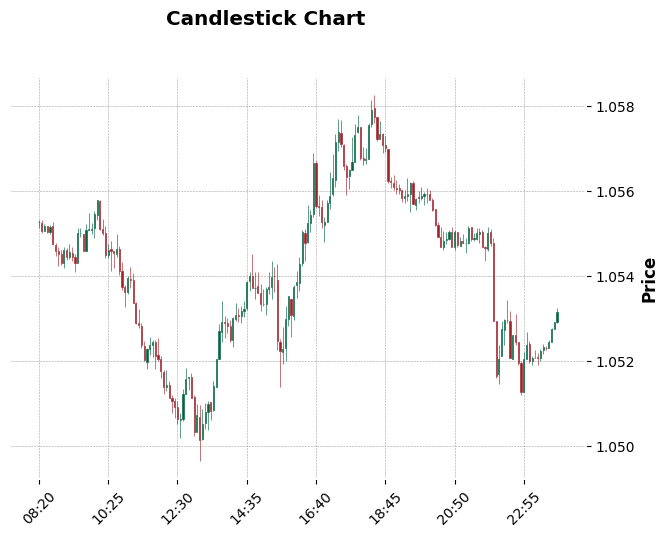

In [84]:
import pandas as pd
import mplfinance as mpf

df = result[100:500]
# Convert 'time' column to datetime and set it as the index
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

# Visualize the candlestick chart
mpf.plot(df, type='candle', style='charles', title='Candlestick Chart', ylabel='Price', volume=False)


In [93]:
df.reset_index(inplace=True)

In [86]:
from functions import *

df = calculate_macd(df)

f:\BullsEye - v5\functions.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['ema_short'] = data['close'].ewm(span=short_period, adjust=False).mean()
f:\BullsEye - v5\functions.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['ema_long'] = data['close'].ewm(span=long_period, adjust=False).mean()
f:\BullsEye - v5\functions.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

In [87]:
df

,time,open,high,low,close,spread_high,spread_low,ema_short,ema_long,MACD,signal_line,MACD_histogram
0,2024-11-14 08:20:00,1.055260,1.055305,1.055120,1.055280,0.00007,0.00004,1.055280,1.055280,0.000000,0.000000,0.000000
1,2024-11-14 08:25:00,1.055255,1.055315,1.055010,1.055060,0.00006,0.00004,1.055246,1.055264,-0.000018,-0.000004,-0.000014
2,2024-11-14 08:30:00,1.055065,1.055220,1.055065,1.055175,0.00007,0.00004,1.055235,1.055257,-0.000022,-0.000007,-0.000015
3,2024-11-14 08:35:00,1.055175,1.055175,1.055020,1.055025,0.00006,0.00004,1.055203,1.055240,-0.000037,-0.000013,-0.000024
4,2024-11-14 08:40:00,1.055025,1.055205,1.054995,1.055155,0.00007,0.00004,1.055196,1.055234,-0.000038,-0.000018,-0.000020
...,...,...,...,...,...,...,...,...,...,...,...,...
183,2024-11-14 23:35:00,1.052310,1.052340,1.052250,1.052300,0.00006,0.00004,1.052289,1.052834,-0.000545,-0.000664,0.000119
184,2024-11-14 23:40:00,1.052300,1.052480,1.052300,1.052435,0.00013,0.00004,1.052312,1.052804,-0.000493,-0.000629,0.000137
185,2024-11-14 23:45:00,1.052455,1.052770,1.052455,1.052740,0.00008,0.00004,1.052378,1.052800,-0.000422,-0.000588,0.000166
186,2024-11-14 23:50:00,1.052745,1.052925,1.052740,1.052915,0.00007,0.00004,1.052460,1.052808,-0.000348,-0.000540,0.000192


In [ ]:
def generate_macd_signals(df):
    """
    Adds a 'signal' column to the DataFrame based on MACD strategy.
    
    Parameters:
        df (pd.DataFrame): A DataFrame containing the MACD line, Signal line, and other columns.
    
    Returns:
        pd.DataFrame: The input DataFrame with an additional 'signal' column.
    """
    # Initialize the 'signal' column with 0 (no signal)
    df['signal'] = 0

    # Generate buy (1) and sell (-1) signals
    for i in range(1, len(df)):
        # Bullish crossover (Buy)
        if df.loc[i, 'MACD'] > df.loc[i, 'signal_line'] and df.loc[i - 1, 'MACD'] <= df.loc[i - 1, 'signal_line']:
            df.loc[i, 'signal'] = 1

        # Bearish crossover (Sell)
        elif df.loc[i, 'MACD'] < df.loc[i, 'signal_line'] and df.loc[i - 1, 'MACD'] >= df.loc[i - 1, 'signal_line']:
            df.loc[i, 'signal'] = -1

    return df

In [89]:
df = generate_macd_signals(df)

C:\Users\hevar\AppData\Local\Temp\ipykernel_17076\1232862117.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['signal'] = 0


In [94]:
df

,time,open,high,low,close,spread_high,spread_low,ema_short,ema_long,MACD,signal_line,MACD_histogram,signal
0,2024-11-14 08:20:00,1.055260,1.055305,1.055120,1.055280,0.00007,0.00004,1.055280,1.055280,0.000000,0.000000,0.000000,0
1,2024-11-14 08:25:00,1.055255,1.055315,1.055010,1.055060,0.00006,0.00004,1.055246,1.055264,-0.000018,-0.000004,-0.000014,-1
2,2024-11-14 08:30:00,1.055065,1.055220,1.055065,1.055175,0.00007,0.00004,1.055235,1.055257,-0.000022,-0.000007,-0.000015,0
3,2024-11-14 08:35:00,1.055175,1.055175,1.055020,1.055025,0.00006,0.00004,1.055203,1.055240,-0.000037,-0.000013,-0.000024,0
4,2024-11-14 08:40:00,1.055025,1.055205,1.054995,1.055155,0.00007,0.00004,1.055196,1.055234,-0.000038,-0.000018,-0.000020,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,2024-11-14 23:35:00,1.052310,1.052340,1.052250,1.052300,0.00006,0.00004,1.052289,1.052834,-0.000545,-0.000664,0.000119,0
184,2024-11-14 23:40:00,1.052300,1.052480,1.052300,1.052435,0.00013,0.00004,1.052312,1.052804,-0.000493,-0.000629,0.000137,0
185,2024-11-14 23:45:00,1.052455,1.052770,1.052455,1.052740,0.00008,0.00004,1.052378,1.052800,-0.000422,-0.000588,0.000166,0
186,2024-11-14 23:50:00,1.052745,1.052925,1.052740,1.052915,0.00007,0.00004,1.052460,1.052808,-0.000348,-0.000540,0.000192,0


In [103]:
from tensorflow.keras.models import load_model


model1 = load_model("model1.h5")
model2 = load_model("model2.h5")
print("Models Loaded Successfully")

Models Loaded Successfully


In [1]:
import time
import logging
import threading
from datetime import datetime

# Setting up logging for debugging and monitoring
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Custom Exception for model errors
class ModelError(Exception):
    pass

# Decorator to measure function execution time
def execution_time_decorator(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        logging.info(f"Execution time: {end_time - start_time:.4f} seconds")
        return result
    return wrapper

# Lambda function for different prediction strategies
predict_strategy = lambda model: "Buy Signal" if model else "No model available"

# Complex perform_predictions function with advanced concepts
@execution_time_decorator  # Measure execution time of this function
def perform_predictions(model=None, check_condition=False):
    """
    Performs a prediction if model exists, or checks a condition if model does not exist.
    """
    if model:
        try:
            # If model exists, perform prediction using a custom prediction strategy
            prediction = model.predict()  # Assuming model has a 'predict' method
            logging.info(f"Prediction: {prediction}")
        except AttributeError as e:
            # Handle case where model doesn't have 'predict' method
            logging.error(f"Error: The model does not have a 'predict' method - {e}")
            raise ModelError("Model has no 'predict' method.")
        except Exception as e:
            # Catching any other exceptions
            logging.error(f"Unexpected error during prediction: {e}")
            raise ModelError("An unexpected error occurred during prediction.")
    else:
        # If model does not exist, simulate checking condition 98 times using threading
        def check_conditions():
            for i in range(98):
                time.sleep(1)  # Simulate delay for checking conditions
                logging.info(f"Checking for Trade")
            logging.info("Trade place")

        # If the `check_condition` is True, run in a separate thread
        if check_condition:
            condition_thread = threading.Thread(target=check_conditions)
            condition_thread.start()
            condition_thread.join()  # Wait for the thread to finish
        else:
            # Otherwise, perform the checks sequentially
            check_conditions()

In [2]:
perform_predictions(check_condition=True)

2024-11-18 00:47:50,541 - INFO - Checking for Trade
2024-11-18 00:47:51,552 - INFO - Checking for Trade
2024-11-18 00:47:52,557 - INFO - Checking for Trade
2024-11-18 00:47:53,564 - INFO - Checking for Trade
2024-11-18 00:47:54,573 - INFO - Checking for Trade
2024-11-18 00:47:55,582 - INFO - Checking for Trade
2024-11-18 00:47:56,588 - INFO - Checking for Trade
2024-11-18 00:47:57,593 - INFO - Checking for Trade
2024-11-18 00:47:58,605 - INFO - Checking for Trade
2024-11-18 00:47:59,618 - INFO - Checking for Trade
2024-11-18 00:48:00,621 - INFO - Checking for Trade
2024-11-18 00:48:01,629 - INFO - Checking for Trade
2024-11-18 00:48:02,634 - INFO - Checking for Trade
2024-11-18 00:48:03,644 - INFO - Checking for Trade
2024-11-18 00:48:04,649 - INFO - Checking for Trade
2024-11-18 00:48:05,664 - INFO - Checking for Trade
2024-11-18 00:48:06,676 - INFO - Checking for Trade
2024-11-18 00:48:07,683 - INFO - Checking for Trade
2024-11-18 00:48:08,692 - INFO - Checking for Trade
2024-11-18 0

In [101]:
import pandas as pd
import plotly.graph_objects as go



# Convert 'time' column to datetime and set it as the index
df['time'] = pd.to_datetime(df['time'])

# Identify the points for buy and sell signals
buy_signals = df[df['signal'] == 1][:1]
sell_signals = df[df['signal'] == -1][:1]

# Create the candlestick chart
candlestick = go.Candlestick(
    x=df['time'],
    open=df['open'],
    high=df['high'],
    low=df['low'],
    close=df['close'],
    name='Candlesticks'
)

# Create scatter plots for Buy and Sell signals with aligned x and y
buy_markers = go.Scatter(
    x=buy_signals['time'],
    y=buy_signals['low'] - 0.0002,  # Slightly below the low price
    mode='markers',
    marker=dict(symbol='triangle-up', color='blue', size=10),
    name='Buy Signal'
)

sell_markers = go.Scatter(
    x=sell_signals['time'],
    y=sell_signals['high'] + 0.0002,  # Slightly above the high price
    mode='markers',
    marker=dict(symbol='triangle-down', color='black', size=10),
    name='Sell Signal'
)

# Create the layout
layout = go.Layout(
    title='Candlestick Chart with Buy and Sell Signals',
    xaxis=dict(title='Time'),
    yaxis=dict(title='Price'),
    height=600  
)

# Combine the data for the plot
fig = go.Figure(data=[candlestick, buy_markers, sell_markers], layout=layout)

# Show the plot
fig.show()


C:\Users\hevar\AppData\Local\Temp\ipykernel_17076\2424061975.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

